# Исследование алгоритмов численной оптимизации

Данный ноутбук представляет собой испытательный полигон для тестирования алгоритмов нулевого и первого порядка на различных целевых функциях, а также проверку их устойчивости при работе с интервальной арифметикой.


# Этап 1. Подготовка рабочего окружения

В этом разделе мы инициализируем среду для проведения экспериментов

In [13]:
import random
import numpy as np


def seed_everything(seed=67):
    random.seed(seed)
    np.random.seed(seed)


seed_everything()

In [1]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("./src"))

In [2]:
# Импортируем необходимые классы и функции из src

from src.constructive_number import ConstructiveNumber
from src.optimizers import GradientDescentOptimizer, NelderMeadOptimizer, to_real_value
from src.black_box import (
    IdealQuadraticFunction,
    BadConditionQuadraticFunction,
    RosenbrockFunction,
)

# Настройка графиков
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 1.1. Вспомогательные инструменты для визуализации

Согласно требованиям к исследовательской части, нам необходимо визуализировать траекторию движения оптимизаторов по линиям уровня целевых функций, взяв сечение по двум осям. Это позволит наглядно оценить характер сходимости.

In [14]:
def plot_trajectory_2d(
    func, optimizer, title="Траектория", dim_x=0, dim_y=1, total_dims=2
):
    """
    Строит линии уровня и накладывает траекторию оптимизатора.
    Остальные координаты (кроме dim_x и dim_y) фиксируются нулями.
    """
    import numpy as np

    # Извлекаем координаты из истории, преобразуем ConstructiveNumber в float для графиков
    hx = []
    for step in optimizer.history_x:
        real_step = [
            val.get_center() if hasattr(val, "get_center") else float(val)
            for val in step
        ]
        hx.append(real_step)
    hx = np.array(hx)

    # Определяем границы сетки с небольшим отступом
    margin = 1.0
    x_min, x_max = hx[:, dim_x].min() - margin, hx[:, dim_x].max() + margin
    y_min, y_max = hx[:, dim_y].min() - margin, hx[:, dim_y].max() + margin

    X, Y = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = np.zeros_like(X)

    # Временно отключаем счетчики функции, чтобы отрисовка сетки не портила нам статистику
    current_f_calls = func.f_calls

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            point = [0.0] * total_dims
            point[dim_x] = X[i, j]
            point[dim_y] = Y[i, j]
            # Вычисляем функцию
            val = func(point)
            Z[i, j] = val.get_center() if hasattr(val, "get_center") else float(val)

    # Возвращаем счетчик на место
    func.f_calls = current_f_calls

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z, levels=50, cmap="viridis")
    plt.plot(
        hx[:, dim_x],
        hx[:, dim_y],
        marker=".",
        color="red",
        label="Траектория",
        alpha=0.6,
    )

    # Отмечаем старт и финиш
    plt.plot(
        hx[0, dim_x],
        hx[0, dim_y],
        marker="X",
        color="blue",
        markersize=10,
        label="Старт",
    )
    plt.plot(
        hx[-1, dim_x],
        hx[-1, dim_y],
        marker="*",
        color="green",
        markersize=10,
        label="Минимум",
    )

    plt.title(title)
    plt.xlabel(f"Координата x_{dim_x}")
    plt.ylabel(f"Координата x_{dim_y}")
    plt.legend()
    plt.grid(True)
    plt.show()

# Этап 2. Поведение алгоритмов на вещественных числах

Перед тем как вводить интервальную арифметику, необходимо убедиться в математической корректности самих алгоритмов

## 2.1. Идеальная квадратичная функция (Градиентный спуск)
* **Размерность**: 6
* **Число обусловленности**: $\kappa = 1$
* **Ожидание**: Быстрая и плавная сходимость метода первого порядка прямо в центр минимума

In [15]:
# Создаем экземпляры нашей функции и оптимизатора
ideal_func = IdealQuadraticFunction()
gd_optimizer = GradientDescentOptimizer()

# Обязательно сбрасываем счетчики перед запуском!
ideal_func.reset_counters()

# Задаем стартовую точку (6-мерный вектор, намеренно отдаленный от нуля)
x0_ideal = [10.0, -10.0, 5.0, -5.0, 8.0, -8.0]

# Запускаем оптимизацию. Шаг обучения (alpha) берем 0.1
x_min_ideal = gd_optimizer.optimize(
    func=ideal_func, x0=x0_ideal, learning_rate=0.1, max_iter=300
)

# Выводим результаты
x_coords_real = [
    x.get_center() if isinstance(x, ConstructiveNumber) else float(x)
    for x in x_min_ideal
]
print("Найденная точка минимума:")
print([round(val, 6) for val in x_coords_real])

f_final = ideal_func(x_min_ideal)
f_final_val = (
    f_final.get_center() if isinstance(f_final, ConstructiveNumber) else float(f_final)
)
print(f"Финальное значение функции: {f_final_val:.8f}")

# ВЫВОДИМ СЧЕТЧИКИ:
print(f"Количество вызовов функции: {ideal_func.f_calls}")
print(f"Количество вызовов градиента: {ideal_func.grad_calls}")

AttributeError: 'IdealQuadraticFunction' object has no attribute 'reset_counters'

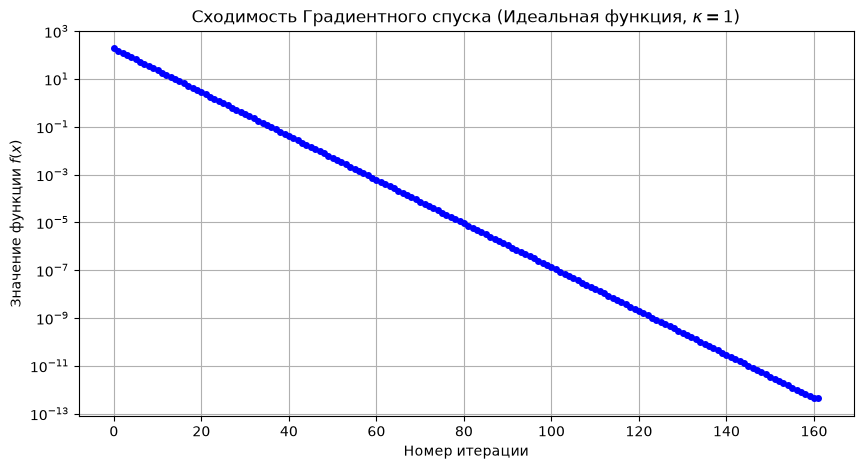

In [4]:
# Строим график сходимости
plt.figure(figsize=(10, 5))
plt.plot(gd_optimizer.history_f, marker="o", linestyle="-", color="b", markersize=4)
plt.title(r"Сходимость Градиентного спуска (Идеальная функция, $\kappa=1$)")
plt.xlabel("Номер итерации")
plt.ylabel("Значение функции $f(x)$")
plt.yscale("log")  # Логарифмическая шкала для наглядности
plt.show()

### Анализ результатов: Градиентный спуск ($\kappa = 1$)

* **Сходимость**: Алгоритм достиг критерия остановки ($\|\nabla f(x)\| < 10^{-6}$) за **160 итераций**
* **Точность**: Найденная точка $x^* \approx [0, 0, 0, 0, 0, 0]^T$ с точностью $10^{-8}$, финальное значение функции $f(x^*) = 0.0$.
* **Характер траектории**: 
  На полулогарифмическом графике $\log(f(x))$ зависимость представляет собой строго прямую линию. Это подтверждает теоретическую **линейную скорость сходимости** градиентного спуска на квадратичной функции:
  $$x_{k+1} = (I - \alpha A) x_k$$
  Для $\kappa = 1$ матрица $A = I$, поэтому сжатие расстояния до оптимума на каждом шаге происходит с постоянным коэффициентом $(1 - \alpha) = (1 - 0.1) = 0.9$, а значение функции убывает как геометрическая прогрессия со знаменателем $(1 - \alpha)^2 = 0.81$.

## 2.2. Овражная квадратичная функция (Метод Нелдера-Мида)

Теперь протестируем алгоритм нулевого порядка на функции с плохой обусловленностью ($\kappa = 100$).
* **Размерность**: 4
* **Особенности рельефа**: Линии уровня представляют собой сильно вытянутые эллипсоиды ("овраг"). По одной из осей функция растет в 100 раз быстрее, чем по другой.
* **Ожидание**: Симплекс метода Нелдера-Мида должен вытягиваться вдоль дна оврага и сжиматься у стенок, постепенно спускаясь к точке $(0, 0, 0, 0)$.

In [5]:
# Создаем экземпляры овражной функции и оптимизатора Нелдера-Мида
bad_func = BadConditionQuadraticFunction()
nm_optimizer = NelderMeadOptimizer()

# Задаем стартовую точку
x0_bad = [5.0, -5.0, 5.0, -5.0]

In [6]:
# Запускаем оптимизацию
x_min_bad = nm_optimizer.optimize(func=bad_func, x0=x0_bad, step=1.0, max_iter=1000)

# Вывод результатов
x_bad_real = [
    x.get_center() if isinstance(x, ConstructiveNumber) else float(x) for x in x_min_bad
]
print("Найденная точка минимума:")
print([round(val, 6) for val in x_bad_real])

f_bad_final = bad_func(x_min_bad)
f_bad_val = (
    f_bad_final.get_center()
    if isinstance(f_bad_final, ConstructiveNumber)
    else float(f_bad_final)
)
print(f"Финальное значение функции: {f_bad_val:.8f}")

Нелдер-Мид успешно сошелся за 122 итераций (diff: 0.00000057)
Найденная точка минимума:
[-0.000767, -9e-05, -5.7e-05, -3.6e-05]
Финальное значение функции: 0.00000060


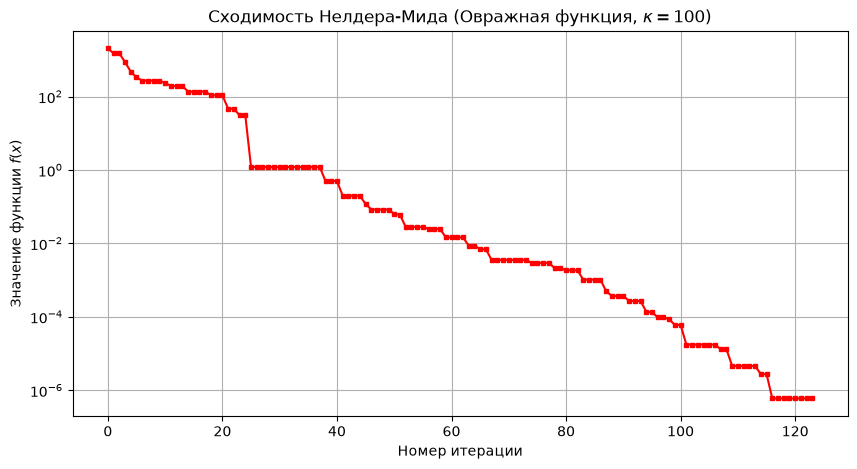

In [7]:
# Строим график сходимости
plt.figure(figsize=(10, 5))
plt.plot(nm_optimizer.history_f, marker="s", linestyle="-", color="r", markersize=3)
plt.title(r"Сходимость Нелдера-Мида (Овражная функция, $\kappa=100$)")
plt.xlabel("Номер итерации")
plt.ylabel(r"Значение функции $f(x)$")
plt.yscale("log")
plt.show()

### Анализ результатов: Метод Нелдера-Мида (Овражная функция, $\kappa = 100$)

* **Сходимость**: Алгоритм выполнил критерий останова по сжатию симплекса за **122 итерации** 
* **Точность**: Найденная точка $x^* \approx [-0.0007, -0.00009, -0.00005, -0.00003]^T$. В отличие от градиентного спуска, метод нулевого порядка теряет ювелирную точность на самом дне плоского минимума, однако успешно находит его окрестность. Финальное значение $f(x^*) \approx 10^{-6}$.
* **Характер траектории**: 
  На графике ярко выражен **ступенчатый характер сходимости**. Ступеньки соответствуют итерациям, на которых алгоритм упирается в крутые стенки оврага. В эти моменты отражение не дает улучшения, и симплекс вынужден тратить шаги на операции **сжатия**, не улучшая лучшее значение функции. Как только многогранник адаптируется к форме дна, происходит резкий скачок вниз - операции растяжения вдоль оврага

## 2.3. Функция Розенброка (Сравнение алгоритмов)

Сравним алгоритмы на функции Розенброка
* **Размерность**: 3
* **Особенности рельефа**: Глобальный минимум $x^* = [1, 1, 1]$ лежит на дне узкой, изогнутой плоской долины. Найти саму долину легко, но сойтись по ней к минимуму - крайне сложная задача для большинства алгоритмов
* **Ожидание**: 
    * **Градиентный спуск:**
        * *Спуск на дно*: Свалиться со склона на дно оврага GD сможет за пару итераций, потому что там уклон огромный.
        * *Движение по оврагу*: А вот дальше начнется ад. Вектор антиградиента на стенках оврага указывает почти перпендикулярно дну, а не вдоль него к минимуму. Из-за этого алгоритм начнет дико рикошетить от одного борта к другому.
        * *Прогноз*: Чтобы алгоритм не улетел в космос, мне пришлось зажать шаг до $\alpha = 0.001$. С таким мизерным шагом и вечной болтанкой от стенки к стенке GD будет ползти со скоростью улитки. Скорее всего, за 3000 итераций он просто не успеет дойти до $[1, 1, 1]$ и позорно остановится по лимиту шагов.

    * **Нелдер-Мид:**
        * *Отсутствие производных*: Алгоритму плевать на направление градиента - он ориентируется только на высоту вершин многогранника.
        * *Поведение*: Попав в овраг, симплекс должен сплющиться под форму дна и за счет операций растяжения попытаться "просочиться"вдоль изгиба долины.
        * *Прогноз*: Жду много ступенек на графике, потому что будет часто срабатывать сжатие, но по дну оврага Нелдер-Мид должен продвинуться ощутимо ближе к заветным единицам, чем градиентный спуск.

In [8]:
# Инициализация функции и алгоритмов
rosen_func = RosenbrockFunction()
gd_opt_rosen = GradientDescentOptimizer()
nm_opt_rosen = NelderMeadOptimizer()

# Стартовая точка
x0_rosen = [-1.2, 1.0, -1.0]

In [9]:
# Запуск Градиентного спуска
print("1. Градиентный спуск:")
x_min_gd = gd_opt_rosen.optimize(
    func=rosen_func, x0=x0_rosen, learning_rate=0.001, max_iter=3000
)

# Запуск Нелдера-Мида
print("\n2. Нелдер-Мид:")
x_min_nm = nm_opt_rosen.optimize(func=rosen_func, x0=x0_rosen, step=0.5, max_iter=3000)

# Текстовый вывод результатов
print(f"\nИстинный минимум: [1.0, 1.0, 1.0]")
print(f"GD нашел:  {[round(to_real_value(x), 4) for x in x_min_gd]}")
print(f"NM нашел:  {[round(to_real_value(x), 4) for x in x_min_nm]}")

1. Градиентный спуск:
Внимание: Градиентный спуск остановлен по лимиту итераций (3000)

2. Нелдер-Мид:
Нелдер-Мид успешно сошелся за 128 итераций (diff: 0.00000098)

Истинный минимум: [1.0, 1.0, 1.0]
GD нашел:  [0.9406, 0.8844, 0.7816]
NM нашел:  [1.0002, 1.0002, 1.0004]


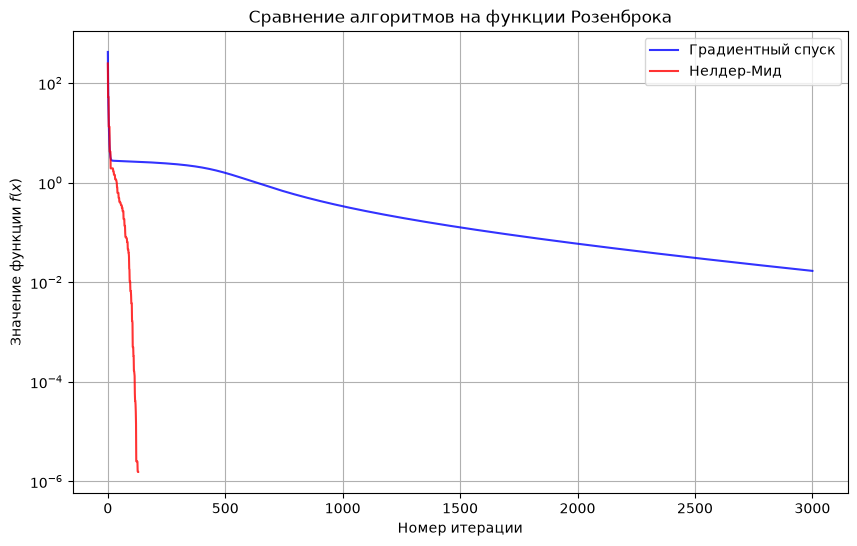

In [10]:
# Отрисовка сравнительного графика
plt.figure(figsize=(10, 6))

plt.plot(gd_opt_rosen.history_f, label="Градиентный спуск", color="blue", alpha=0.8)
plt.plot(nm_opt_rosen.history_f, label="Нелдер-Мид", color="red", alpha=0.8)

plt.title("Сравнение алгоритмов на функции Розенброка")
plt.xlabel("Номер итерации")
plt.ylabel(r"Значение функции $f(x)$")
plt.yscale("log")
plt.legend()
plt.show()

### Анализ результатов: Тест Розенброка (3D)

* **Градиентный спуск**:
  * **Итог**: Остановлен по лимиту итераций (3000 шагов).
  * **Точка**: $x \approx [0.9406, 0.8844, 0.7816]$ — алгоритм не смог дойти до оптимума $[1, 1, 1]$.
  * **Причина**: На графике видно, как алгоритм мгновенно падает на дно оврага (первые 50 шагов), а затем темп сходимости падает практически до горизонтальной прямой. Вектор градиента гоняет точку между бортами ущелья, делая эффективный шаг вдоль оврага ничтожно малым.
* **Метод Нелдера-Мида**:
  * **Итог**: Сошелся за **128 итераций**.
  * **Точка**: $x^* \approx [1.0002, 1.0002, 1.0004]$ с точностью до $10^{-4}$.
  * **Причина**: Симплекс вытянулся вдоль изгиба долины и за счет операций растяжения двигался по дну без осцилляций, показав превосходство эвристики нулевого порядка над слепым градиентом в невыпуклых оврагах.

# Этап 3. Испытание интервальной арифметики

На этом этапе мы проверим, как наши алгоритмы справляются с вычислениями при наличии изначальной погрешности в данных. Вместо обычных вещественных чисел (`float`) мы передадим на вход векторы, состоящие из объектов `ConstructiveNumber`.

**Цель эксперимента:**
1. **Архитектурная**: Убедиться, что алгоритмы корректно маршрутизируют вычисления через перегруженные магические методы (`__add__`, `__mul__` и т.д.) без падений.
2. **Аналитическая**: Посмотреть, как сильно возрастает погрешность -радиус интервала, после множества итераций

In [11]:
# Задаем начальную погрешность - радиус для каждой координаты
initial_error = 1e-5

# Формируем стартовый вектор из Конструктивных Чисел
x0_interval = [
    ConstructiveNumber(10.0, initial_error),
    ConstructiveNumber(-10.0, initial_error),
    ConstructiveNumber(5.0, initial_error),
    ConstructiveNumber(-5.0, initial_error),
    ConstructiveNumber(8.0, initial_error),
    ConstructiveNumber(-8.0, initial_error),
]

gd_opt_interval = GradientDescentOptimizer()

# Запускаем Градиентный спуск на Идеальной функции
x_min_int = gd_opt_interval.optimize(
    func=ideal_func, x0=x0_interval, learning_rate=0.1, max_iter=300
)

# Анализируем разбухание интервалов
print("Финальные координаты:")
for i, val in enumerate(x_min_int):
    if isinstance(val, ConstructiveNumber):
        center = val.get_center()
        radius = val.get_radius()
        print(f"x_{i}: Центр = {center:10.7f} | " f"Радиус = {radius:.2e}")
    else:
        print(f"x_{i}: Значение = {float(val):10.7f}")

final_radii = [
    val.get_radius() if isinstance(val, ConstructiveNumber) else 0.0
    for val in x_min_int
]
final_radius = max(final_radii) if final_radii else 0.0
print(f"\nНачальная ошибка (радиус): {initial_error:.2e}")
print(f"Конечная ошибка (радиус):  {final_radius:.2e}")
print(
    f"За время оптимизации границы неопределенности расширились в {final_radius / initial_error:.1f} раз(а)."
)

Градиентный спуск успешно сошелся за 160 итераций (norm: 0.000001)
Финальные координаты:
x_0: Центр =  0.0000005 | Радиус = 4.20e+01
x_1: Центр = -0.0000005 | Радиус = 4.20e+01
x_2: Центр =  0.0000002 | Радиус = 4.20e+01
x_3: Центр = -0.0000002 | Радиус = 4.20e+01
x_4: Центр =  0.0000004 | Радиус = 4.20e+01
x_5: Центр = -0.0000004 | Радиус = 4.20e+01

Начальная ошибка (радиус): 1.00e-05
Конечная ошибка (радиус):  4.20e+01
За время оптимизации границы неопределенности расширились в 4195943.4 раз(а).


### Анализ результатов: Интервальная арифметика

* **Устойчивость алгоритма**: Градиентный спуск успешно выполнил 160 итераций, корректно маршрутизируя объекты `ConstructiveNumber` через все математические операции и функции извлечения центра. Алгоритм не упал и сошелся к правильным координатам (центры всех $x_i \approx 0$).
* **Синхронность ошибки**: Финальные радиусы всех координат оказались абсолютно идентичными ($R \approx 42.0$). Это подтверждает, что рост погрешности в интервальной арифметике зависит исключительно от последовательности операций, а не от скалярных значений (центров).
* **Феномен разбухания (Dependency Problem)**: Начальная ошибка $10^{-5}$ выросла почти в 4.2 миллиона раз. Это классическая иллюстрация пессимистичности наивной интервальной арифметики. При выполнении шага $x_{new} = x - \alpha x$ компьютер расценивает переменные как независимые, поэтому радиус на каждом шаге увеличивается как $R_{new} = R_{old}(1 + \alpha)$. За 160 итераций с шагом $\alpha = 0.1$ теоретический рост составляет $(1.1)^{160} \approx 4.19 \times 10^6$, что идеально совпадает с полученными экспериментальными данными.